In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

In [ ]:
# TAREA 1: Descargar y cargar el conjunto CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()



In [ ]:
# TAREA 2: Normalizar los datos
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# TAREA 3: Convertir las etiquetas en un formato categórico
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


In [ ]:
# TAREA 4: Imprimir la forma (shape) de x_train y y_train
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")


x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)


In [ ]:
# Definir el modelo
model = Sequential([
    # TAREA 5: Agregar una capa de convolución
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),

    # TAREA 6: Agregar una capa de pooling
    MaxPooling2D(pool_size=(2, 2)),

    # TAREA 7: Aplanar los datos
    Flatten(),

    # TAREA 8: Agregar una capa densa oculta
    Dense(128, activation='relu'),

    # TAREA 9: Agregar la capa de salida
    Dense(10, activation='softmax')
])


In [ ]:
# TAREA 10: Configurar y compilar el modelo
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Entrenar el modelo
model.fit(x_train, y_train, epochs=10, batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - accuracy: 0.3944 - loss: 1.6999
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.5813 - loss: 1.1843
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accuracy: 0.6232 - loss: 1.0749
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.6524 - loss: 0.9912
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.6785 - loss: 0.9321
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.7002 - loss: 0.8611
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 58ms/step - accuracy: 0.7157 - loss: 0.8219
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.7361 - loss: 0.7650
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.7503 - loss: 0.7220
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 58ms/step - accuracy: 0.7638 - loss: 0.6702


In [ ]:
# Evaluar el modelo
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Precisión en el conjunto de prueba: {test_accuracy:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6453 - loss: 1.0361
Precisión en el conjunto de prueba: 0.64


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


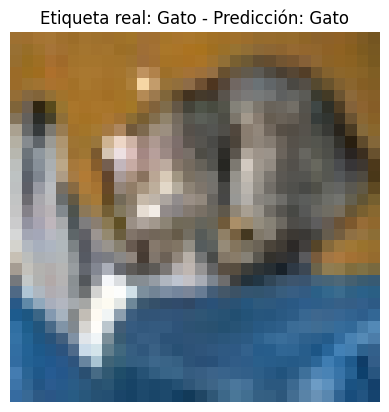

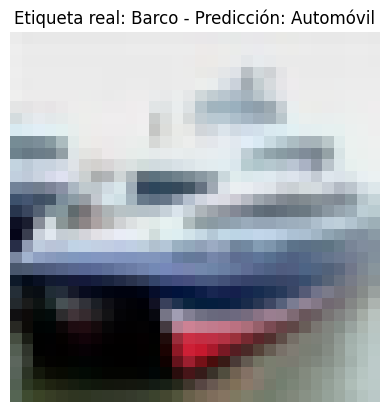

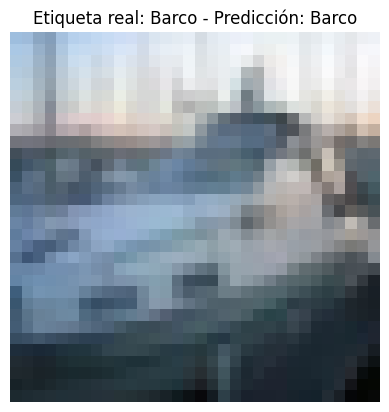

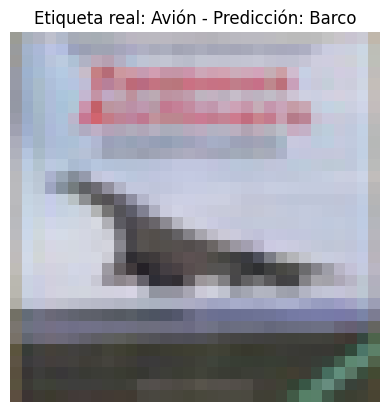

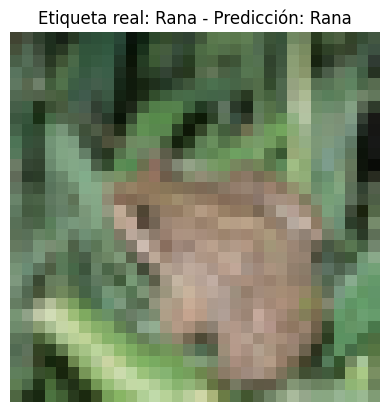

In [ ]:
# Visualizar resultados
predictions = model.predict(x_test[:5])
class_names = ['Avión', 'Automóvil', 'Pájaro', 'Gato', 'Ciervo', 'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']
for i in range(5):
    plt.imshow(x_test[i])
    plt.title(f"Etiqueta real: {class_names[y_test[i].argmax()]} - Predicción: {class_names[predictions[i].argmax()]}")
    plt.axis('off')
    plt.show()

Parte B: Revisión de errores
Error en from tensorflow.kera.datasets: Falta la "s" en keras.
Error en adam: Debe ser Adam() y correctamente importado.
Error en batch_sise: Es batch_size.
Error en plt.shouw(): Es plt.show().
Error en class_name: Debe ser class_names.
Error en etiquetas reales: y_test[i].argmax() solo funciona si y_test ya está en formato one-hot encoding.

Parte C: Reflexión técnica
Modificaciones al modelo y datos:

Filtrar CIFAR-10 para quedarnos solo con las categorías relevantes (automóvil, camión, barco y avión).
Aumentar la resolución de las imágenes si es posible.
Usar transferencia de aprendizaje con un modelo preentrenado como MobileNet o ResNet.

In [ ]:
#Código de ejemplo para filtrar datos:
import numpy as np
selected_classes = [0, 1, 8, 9]  # Índices para avión, automóvil, barco, camión
train_mask = np.isin(y_train.argmax(axis=1), selected_classes)
test_mask = np.isin(y_test.argmax(axis=1), selected_classes)

x_train, y_train = x_train[train_mask], y_train[train_mask]
x_test, y_test = x_test[test_mask], y_test[test_mask]

Pasos para producción:

Optimización del modelo: Reducir tamaño y complejidad para implementarlo en tiempo real.
Integración: Usar OpenCV o TensorFlow Lite para procesar imágenes en cámaras.
Evaluación constante: Monitorear métricas en producción.

In [ ]:
#Código para conversión a TensorFlow Lite:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpigidjr4d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137794767601904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137794611463792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137794611465904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137794611464496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137794611466784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137794611468368: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
#Pregunta 2: Traductor
from transformers import MarianMTModel, MarianTokenizer

def translate_to_german(text):
    # Cargar modelo preentrenado de traducción
    model_name = "Helsinki-NLP/opus-mt-es-de"
    tokenizer = MarianTokenizer.from_pretrained(model_name)
    model = MarianMTModel.from_pretrained(model_name)

    # Tokenizar el texto
    tokens = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    # Realizar la traducción
    translated = model.generate(**tokens)
    translation = tokenizer.decode(translated[0], skip_special_tokens=True)

    return translation

# Probar la función
text = "Codigo Lagarto chocolatada caliente o Sideral frío gaaaaaaaaa"
print("Traducción:", translate_to_german(text))

Traducción: Code Heiße Schoko-Eidechse oder Kalte Sideral Gaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa
